# 02 — La macchina della verità

Prendiamo le quattro strategie classiche e chiediamo, per SPY e AAPL:
1. Quanto rendono **dopo i costi**?
2. Battono **buy & hold**?
3. Reggono su dati **mai visti** (out-of-sample, walk-forward)?
4. Il risultato è distinguibile dalla **fortuna** (bootstrap)?

Regole: parametri scelti solo sul primo 70% dei dati; costi 0,10% + 0,05% per operazione; seed fisso (42) per il bootstrap.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from quantlab.backtest import run_backtest
from quantlab.data import load_prices
from quantlab.metrics import drawdown
from quantlab.report import evaluate_strategy, format_report
from quantlab.strategies import mean_reversion, momentum, moving_average_crossover
from quantlab.validation import param_grid, sharpe_difference_bootstrap

COLORS = {"strategy": "#2a78d6", "buy_and_hold": "#eb6834"}  # fixed colour per series
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#e4e4e0", "grid.linewidth": 0.8,
    "lines.linewidth": 1.5, "figure.dpi": 110,
})

prices = load_prices(["SPY", "AAPL"], "2015-01-01", "2025-12-31", cache_dir="../data")

## 1. Un backtest a mano: costi e shift

Incrocio di medie mobili 50/200 su SPY. Guardiamo le colonne del backtest e quanto si mangiano i costi.

In [2]:
spy = prices["SPY"]
bt = run_backtest(spy, moving_average_crossover(spy, fast=50, slow=200))
trades = (bt["position"].diff().abs() > 0).sum()
print(f"Trades: {trades}")
print(f"Gross total return: {(1 + bt['gross_return']).prod() - 1:.1%}")
print(f"Net total return:   {(1 + bt['net_return']).prod() - 1:.1%}")
bt.loc[bt["position"].diff().abs() > 0].head(3)

Trades: 11
Gross total return: 141.2%
Net total return:   137.2%


,position,asset_return,gross_return,cost,net_return,equity
Date,,,,,,
2015-12-10,1.0,0.002581,0.002581,0.0015,0.001081,1.001081
2016-01-19,0.0,0.001331,0.000000,0.0015,-0.001500,0.917318
2016-04-21,1.0,-0.005378,-0.005378,0.0015,-0.006878,0.911009


Nelle righe sopra: il giorno in cui `position` cambia è il giorno **dopo** il segnale, e solo quel giorno compare un `cost`.

## 2. Tutte le strategie, tutti i ticker

Per ogni strategia diamo una piccola griglia di parametri: la scelta avviene solo in-sample, il giudizio sull'out-of-sample.

In [3]:
GRIDS = {
    "momentum": (momentum, param_grid(lookback=[126, 252], skip=[0, 21])),
    "ma_crossover": (moving_average_crossover, param_grid(fast=[20, 50], slow=[100, 200])),
    "mean_reversion": (mean_reversion, param_grid(window=[10, 20], entry_z=[-1.5, -1.0])),
}

reports, rows = {}, []
for ticker in prices.columns:
    for name, (strategy, grid) in GRIDS.items():
        r = evaluate_strategy(prices[ticker], strategy, grid=grid, name=f"{name} on {ticker}")
        reports[(ticker, name)] = r
        oos, wf = r.out_of_sample, r.walk_forward
        rows.append({
            "ticker": ticker, "strategy": name, "params": r.params,
            "OOS sharpe": oos.loc["sharpe", "strategy"],
            "OOS sharpe B&H": oos.loc["sharpe", "buy_and_hold"],
            "diff 95% CI": f"{r.sharpe_diff_ci[0]:+.2f} .. {r.sharpe_diff_ci[1]:+.2f}",
            "WF sharpe": wf.loc["sharpe", "strategy"],
            "WF sharpe B&H": wf.loc["sharpe", "buy_and_hold"],
            "verdict": r.verdict.split()[0] + (" EVIDENCE" if r.verdict.startswith("NO") else ""),
        })

verdicts = pd.DataFrame(rows).round(2)
verdicts

,ticker,strategy,params,OOS sharpe,OOS sharpe B&H,diff 95% CI,WF sharpe,WF sharpe B&H,verdict
0,SPY,momentum,"{'lookback': 252, 'skip': 21}",1.23,1.16,-0.47 .. +0.56,0.62,0.78,NO EVIDENCE
1,SPY,ma_crossover,"{'fast': 20, 'slow': 100}",1.04,1.16,-0.76 .. +0.60,0.48,0.78,NO EVIDENCE
2,SPY,mean_reversion,"{'window': 20, 'entry_z': -1.5}",0.34,1.16,-1.77 .. -0.22,0.06,0.78,WORSE
3,AAPL,momentum,"{'lookback': 126, 'skip': 0}",0.30,0.78,-1.12 .. +0.36,0.65,0.93,NO EVIDENCE
4,AAPL,ma_crossover,"{'fast': 50, 'slow': 200}",0.08,0.78,-1.50 .. +0.04,0.44,0.93,NO EVIDENCE
5,AAPL,mean_reversion,"{'window': 10, 'entry_z': -1.0}",0.28,0.78,-1.49 .. +0.13,0.12,0.93,NO EVIDENCE


## 3. Un report completo

Il report che si ottiene con **una sola chiamata** a `evaluate_strategy` + `format_report`.

In [4]:
TICKER, NAME = "SPY", "momentum"
report = reports[(TICKER, NAME)]
print(format_report(report))

STRATEGY REPORT: momentum on SPY {'lookback': 252, 'skip': 21}
Period 2015-01-02 -> 2025-12-30, out-of-sample from 2022-09-09
Costs per trade: commission 0.10%, slippage 0.05%

VERDICT: NO EVIDENCE it beats buy & hold: out-of-sample, the Sharpe difference is within what luck alone can produce (95% bootstrap interval contains zero).
  Out-of-sample Sharpe difference +0.07 (95% interval -0.47 to +0.56; strategy ahead in 43% of bootstrap samples)

IN-SAMPLE (used to choose parameters)
                  strategy buy_and_hold
total_return         55.1%       123.3%
annual_return         5.9%        11.0%
annual_volatility    16.3%        18.3%
sharpe                0.43         0.66
max_drawdown        -33.7%       -33.7%

OUT-OF-SAMPLE (never seen while choosing)
                  strategy buy_and_hold
total_return         68.8%        80.1%
annual_return        17.2%        19.5%
annual_volatility    13.7%        16.6%
sharpe                1.23         1.16
max_drawdown        -18.8%    

## 4. Out-of-sample: equity e drawdown

Entrambe le curve partono da 1 il primo giorno out-of-sample. Un solo asse: la stessa unità (crescita di 1 €) per entrambe.

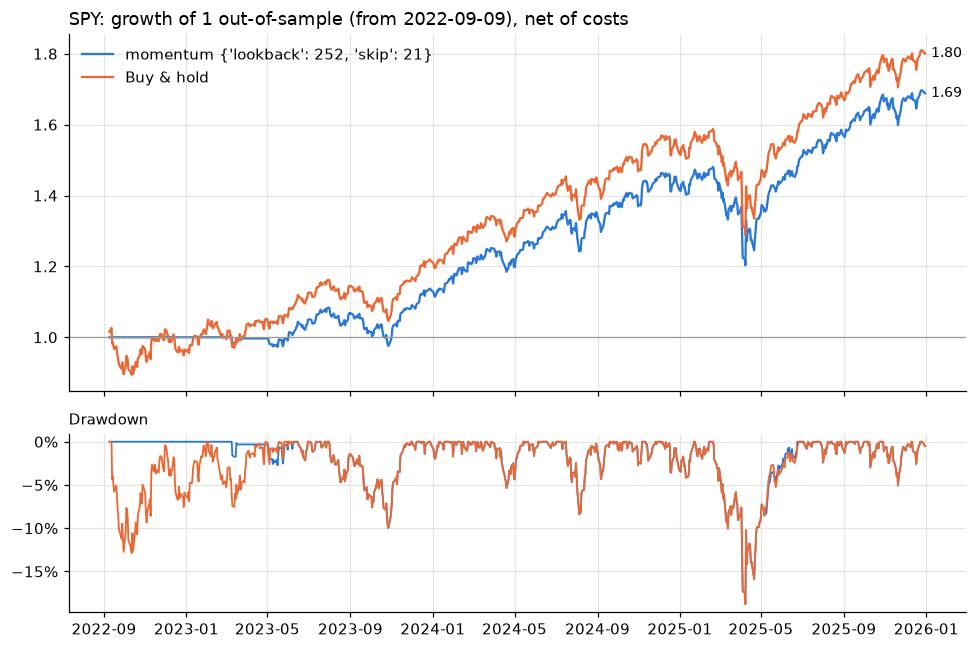

In [5]:
oos = report.returns[report.returns.index >= report.split]
equity = (1 + oos).cumprod()
dd = oos.apply(drawdown)
labels = {"strategy": f"{NAME} {report.params}", "buy_and_hold": "Buy & hold"}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True, height_ratios=[2, 1])
for col in equity.columns:
    ax1.plot(equity.index, equity[col], color=COLORS[col], label=labels[col])
    ax1.annotate(f"{equity[col].iloc[-1]:.2f}", (equity.index[-1], equity[col].iloc[-1]),
                 xytext=(4, 0), textcoords="offset points", va="center", fontsize=9)
    ax2.plot(dd.index, dd[col], color=COLORS[col], linewidth=1.2)
ax1.axhline(1, color="#9a9a94", linewidth=0.8)
ax1.set_title(f"{TICKER}: growth of 1 out-of-sample (from {report.split.date()}), net of costs", loc="left")
ax1.legend(frameon=False, loc="upper left")
ax2.set_title("Drawdown", loc="left", fontsize=10)
ax2.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0, decimals=0))
fig.tight_layout()
plt.show()

## 5. Fortuna o abilità? Il bootstrap

Ricostruiamo 1000 storie alternative incollando blocchi di 20 giorni presi a caso dal periodo out-of-sample (sempre gli stessi giorni per strategia e benchmark) e ricalcoliamo la differenza di Sharpe. Se la distribuzione è a cavallo dello zero, il vantaggio non è distinguibile dalla fortuna.

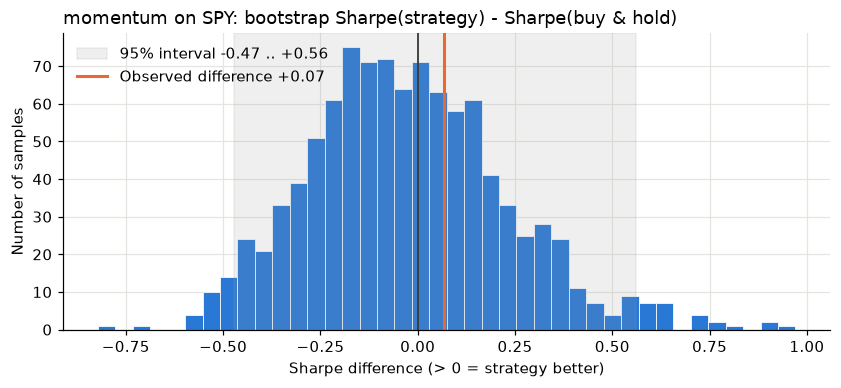

Strategy ahead in 43% of the samples


In [6]:
samples = sharpe_difference_bootstrap(oos["strategy"], oos["buy_and_hold"], n_samples=1000, seed=42)
low, high = report.sharpe_diff_ci

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(samples, bins=40, color=COLORS["strategy"], edgecolor="white", linewidth=0.5)
ax.axvline(0, color="#3a3a36", linewidth=1.2)
ax.axvspan(low, high, color="#9a9a94", alpha=0.15, label=f"95% interval {low:+.2f} .. {high:+.2f}")
ax.axvline(report.sharpe_diff, color=COLORS["buy_and_hold"], linewidth=2,
           label=f"Observed difference {report.sharpe_diff:+.2f}")
ax.set_title(f"{NAME} on {TICKER}: bootstrap Sharpe(strategy) - Sharpe(buy & hold)", loc="left")
ax.set_xlabel("Sharpe difference (> 0 = strategy better)")
ax.set_ylabel("Number of samples")
ax.legend(frameon=False, loc="upper left")
plt.show()
print(f"Strategy ahead in {np.mean(samples > 0):.0%} of the samples")

## Conclusioni (dati 2015–2025, costi inclusi)

1. **Nessuna strategia batte buy & hold in modo distinguibile dalla fortuna.** Su 6 combinazioni
   (3 strategie × 2 ticker), 5 risultano "NO EVIDENCE" e una (mean reversion su SPY) è
   peggiore in modo netto: l'intervallo bootstrap è tutto sotto zero.
2. **Il walk-forward è il test più severo, e qui tutte perdono.** Lo Sharpe in walk-forward è
   sempre più basso di quello di buy & hold (es. SPY momentum 0,62 contro 0,78). L'out-of-sample
   singolo è un solo periodo di circa 3 anni e può essere fortunato; il walk-forward ne mette
   insieme 8.
3. **Uno Sharpe più alto non vuol dire guadagnare di più.** Il momentum su SPY ha Sharpe
   out-of-sample 1,23 contro 1,16, ma alla fine ha 1,69 € contro 1,80 €. Lo Sharpe è più alto
   perché la strategia è rimasta in liquidità nei primi mesi (volatilità più bassa), non perché
   abbia preso più rialzi.
4. **Il momentum "lento" non evita i crolli veloci.** Il drawdown di aprile 2025 è identico a
   quello di buy & hold: un segnale su 12 mesi (meno l'ultimo) reagisce dopo settimane, mentre il
   crollo è durato pochi giorni.

### Limiti di questa analisi (da dire sempre)
- Due soli ticker, scelti **oggi**: survivorship bias, i risultati veri sarebbero peggiori.
- Un solo mercato rialzista lungo (2015–2025): stare investiti è stato premiato. In un decennio
  laterale le strategie con uscite potrebbero andare diversamente.
- Griglie piccole (4 combinazioni) apposta: più combinazioni provi, più è facile trovarne una che
  "funziona" per caso.
- Questo è uno strumento di ricerca, non un consiglio di investimento.
